In [ ]:
from pathlib import Path
import pandas as pd

# 3. RUTAS DEL PROYECTO
BASE_DIR = Path(".")
DATA_DIR = BASE_DIR / "data"
OUTPUT_DIR = BASE_DIR / "outputs"
MODEL_DIR = BASE_DIR / "models"

OUTPUT_CAP4 = OUTPUT_DIR / "capitulo_4"
OUTPUT_CAP5 = OUTPUT_DIR / "capitulo_5"

DATA_PATH = DATA_DIR / "BDF.xlsx"

for folder in [DATA_DIR, OUTPUT_DIR, MODEL_DIR, OUTPUT_CAP4, OUTPUT_CAP5]:
    folder.mkdir(parents=True, exist_ok=True)

# ============================================================
# BLOQUE OPCIONAL SOLO PARA COLAB
# ============================================================

try:
    from google.colab import files
    uploaded = files.upload()

    import shutil

    for filename in uploaded.keys():
        shutil.move(filename, DATA_PATH)

    print("Archivo subido y guardado como data/BDF.xlsx")

except:
    pass


if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"No se encontró el archivo {DATA_PATH}. "
        "Coloca la base BDF.xlsx dentro de la carpeta data antes de ejecutar el script."
    )

df = pd.read_excel(DATA_PATH)

Saving BDF.xlsx to BDF.xlsx
Archivo subido y guardado como data/BDF.xlsx


In [ ]:
# ============================================================
# TESIS - PREDICCIÓN DE DESERCIÓN ESTUDIANTIL
# Pipeline reproducible para análisis, modelado e interpretación
# ============================================================

# Este script prepara el entorno de trabajo, carga la base de datos
# y deja registradas las versiones principales para facilitar la
# replicabilidad del análisis.

# ============================================================
# 1. LIBRERÍAS
# ============================================================

import os
import sys
import json
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn import __version__ as sklearn_version
import xgboost
import shap

warnings.filterwarnings("ignore")

# ============================================================
# 2. CONFIGURACIÓN GENERAL
# ============================================================

RANDOM_STATE = 42

np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 1000)

# ============================================================
# 3. RUTAS DEL PROYECTO
# ============================================================

BASE_DIR = Path(".")
DATA_DIR = BASE_DIR / "data"
OUTPUT_DIR = BASE_DIR / "outputs"
MODEL_DIR = BASE_DIR / "models"

OUTPUT_CAP4 = OUTPUT_DIR / "capitulo_4"
OUTPUT_CAP5 = OUTPUT_DIR / "capitulo_5"

DATA_PATH = DATA_DIR / "BDF.xlsx"

for folder in [DATA_DIR, OUTPUT_DIR, MODEL_DIR, OUTPUT_CAP4, OUTPUT_CAP5]:
    folder.mkdir(parents=True, exist_ok=True)

# ============================================================
# 4. REGISTRO DE VERSIONES
# ============================================================

versions = {
    "python": sys.version,
    "numpy": np.__version__,
    "pandas": pd.__version__,
    "sklearn": sklearn_version,
    "xgboost": xgboost.__version__,
    "shap": shap.__version__
}

with open(OUTPUT_DIR / "versions.json", "w", encoding="utf-8") as file:
    json.dump(versions, file, indent=4, ensure_ascii=False)

print("Versiones registradas en outputs/versions.json")

# ============================================================
# 5. CARGA DE DATOS
# ============================================================

if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"No se encontró el archivo {DATA_PATH}. "
        "Coloca la base BDF.xlsx dentro de la carpeta data antes de ejecutar el script."
    )

df = pd.read_excel(DATA_PATH)

# Limpieza básica de nombres de columnas
df.columns = df.columns.str.strip()

print("Base cargada correctamente")
print("Dimensiones iniciales:", df.shape)
print("Primeras filas:")
print(df.head())

Versiones registradas en outputs/versions.json
Base cargada correctamente
Dimensiones iniciales: (4424, 37)
Primeras filas:
   Marital status  Application mode  Application order  Course  Daytime/evening attendance  Previous qualification  Previous qualification (grade)  Nacionality  Mother's qualification  Father's qualification  Mother's occupation  Father's occupation  Admission grade  Displaced  Educational special needs  Debtor  Tuition fees up to date  Gender  Scholarship holder  Age at enrollment  International  Curricular units 1st sem (credited)  Curricular units 1st sem (enrolled)  Curricular units 1st sem (evaluations)  Curricular units 1st sem (approved)  Curricular units 1st sem (grade)  Curricular units 1st sem (without evaluations)  Curricular units 2nd sem (credited)  Curricular units 2nd sem (enrolled)  Curricular units 2nd sem (evaluations)  Curricular units 2nd sem (approved)  Curricular units 2nd sem (grade)  Curricular units 2nd sem (without evaluations)  Unemploym

In [ ]:
# ============================================================
# 6. REVISIÓN GENERAL DE LA BASE DE DATOS
# ============================================================

print("\n==============================")
print("TIPOS DE DATOS")
print("==============================")
print(df.dtypes)

# -------------------------------
# Valores nulos
# -------------------------------

print("\n==============================")
print("VALORES NULOS")
print("==============================")

nulos = df.isnull().sum()
nulos_total = int(nulos.sum())

if nulos_total == 0:
    print("No se encontraron valores nulos en la base de datos.")
else:
    print(nulos[nulos > 0])

print("Total de valores nulos:", nulos_total)

# -------------------------------
# Duplicados
# -------------------------------

print("\n==============================")
print("DUPLICADOS")
print("==============================")

duplicados = df.duplicated().sum()
print("Número de registros duplicados:", int(duplicados))

if duplicados > 0:
    df = df.drop_duplicates().copy()
    print("Duplicados eliminados.")
    print("Nueva dimensión:", df.shape)
else:
    print("No se encontraron duplicados.")


# ============================================================
# 7. TRANSFORMACIÓN DE VARIABLE OBJETIVO
# ============================================================

# Variable original:
# Target = Dropout / Enrolled / Graduate

# Transformación a binario:
# 1 = Dropout (deserción)
# 0 = No deserción (Enrolled + Graduate)

df["target_dropout"] = df["Target"].map({
    "Dropout": 1,
    "Enrolled": 0,
    "Graduate": 0
})

# Validación de transformación
print("\n==============================")
print("VALIDACIÓN DEL TARGET")
print("==============================")

print(df[["Target", "target_dropout"]].head())

print("\nTabla cruzada:")
print(pd.crosstab(df["Target"], df["target_dropout"]))

# -------------------------------
# Distribución del target
# -------------------------------

print("\n==============================")
print("DISTRIBUCIÓN DEL TARGET")
print("==============================")

conteo = df["target_dropout"].value_counts()
porcentaje = df["target_dropout"].value_counts(normalize=True)

print("Frecuencia:")
print(conteo)

print("\nProporción:")
print(porcentaje.round(4))

# ============================================================
# 8. DEFINICIÓN DE VARIABLES X e y
# ============================================================

X = df.drop(columns=["Target", "target_dropout"])
y = df["target_dropout"]

print("\nVariables independientes:", X.shape[1])
print("Variable dependiente: target_dropout")

# ============================================================
# 9. GUARDADO BASE LIMPIA
# ============================================================

df.to_excel(OUTPUT_CAP4 / "base_limpia.xlsx", index=False)

print("\nBase limpia guardada en:")
print(OUTPUT_CAP4 / "base_limpia.xlsx")


TIPOS DE DATOS
Marital status                                      int64
Application mode                                    int64
Application order                                   int64
Course                                              int64
Daytime/evening attendance                          int64
Previous qualification                              int64
Previous qualification (grade)                    float64
Nacionality                                         int64
Mother's qualification                              int64
Father's qualification                              int64
Mother's occupation                                 int64
Father's occupation                                 int64
Admission grade                                   float64
Displaced                                           int64
Educational special needs                           int64
Debtor                                              int64
Tuition fees up to date                             int6

In [ ]:
df. head(10)

,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,Mother's occupation,Father's occupation,Admission grade,Displaced,Educational special needs,Debtor,Tuition fees up to date,Gender,Scholarship holder,Age at enrollment,International,Curricular units 1st sem (credited),Curricular units 1st sem (enrolled),Curricular units 1st sem (evaluations),Curricular units 1st sem (approved),Curricular units 1st sem (grade),Curricular units 1st sem (without evaluations),Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target,target_dropout
0,1,17,5,171,1,1,122.0,1,19,12,5,9,127.3,1,0,0,1,1,0,20,0,0,0,0,0,0.000000e+00,0,0,0,0,0,0.000000e+00,0,10.8,1.4,1.74,Dropout,1
1,1,15,1,9254,1,1,160.0,1,1,3,3,3,142.5,1,0,0,0,1,0,19,0,0,6,6,6,1.400000e+01,0,0,6,6,6,1.366667e+16,0,13.9,-0.3,0.79,Graduate,0
2,1,1,5,9070,1,1,122.0,1,37,37,9,9,124.8,1,0,0,0,1,0,19,0,0,6,0,0,0.000000e+00,0,0,6,0,0,0.000000e+00,0,10.8,1.4,1.74,Dropout,1
3,1,17,2,9773,1,1,122.0,1,38,37,5,3,119.6,1,0,0,1,0,0,20,0,0,6,8,6,1.342857e+16,0,0,6,10,5,1.240000e+01,0,9.4,-0.8,-3.12,Graduate,0
4,2,39,1,8014,0,1,100.0,1,37,38,9,9,141.5,0,0,0,1,0,0,45,0,0,6,9,5,1.233333e+16,0,0,6,6,6,1.300000e+01,0,13.9,-0.3,0.79,Graduate,0
5,2,39,1,9991,0,19,133.1,1,37,37,9,7,114.8,0,0,1,1,1,0,50,0,0,5,10,5,1.185714e+16,0,0,5,17,5,1.150000e+01,5,16.2,0.3,-0.92,Graduate,0
6,1,1,1,9500,1,1,142.0,1,19,38,7,10,128.4,1,0,0,1,0,1,18,0,0,7,9,7,1.330000e+01,0,0,8,8,8,1.434500e+04,0,15.5,2.8,-4.06,Graduate,0
7,1,18,4,9254,1,1,119.0,1,37,37,9,9,113.1,1,0,0,0,1,0,22,0,0,5,5,0,0.000000e+00,0,0,5,5,0,0.000000e+00,0,15.5,2.8,-4.06,Dropout,1
8,1,1,3,9238,1,1,137.0,62,1,1,9,9,129.3,0,0,0,1,0,1,21,1,0,6,8,6,1.387500e+04,0,0,6,7,6,1.414286e+16,0,16.2,0.3,-0.92,Graduate,0
9,1,1,1,9238,1,1,138.0,1,1,19,4,7,123.0,1,0,1,0,0,0,18,0,0,6,9,5,1.140000e+01,0,0,6,14,2,1.350000e+01,0,8.9,1.4,3.51,Dropout,1


In [ ]:
# ============================================================
# 10. IDENTIFICACIÓN DE VARIABLES
# ============================================================

# Variables que vienen codificadas como números pero son categóricas
categoricas_codificadas = [
    "Marital status",
    "Application mode",
    "Application order",
    "Course",
    "Daytime/evening attendance",
    "Previous qualification",
    "Nacionality",
    "Mother's qualification",
    "Father's qualification",
    "Mother's occupation",
    "Father's occupation",
    "Displaced",
    "Educational special needs",
    "Debtor",
    "Tuition fees up to date",
    "Gender",
    "Scholarship holder",
    "International"
]

# Filtrar solo las que existen en la base
categoricas_codificadas = [col for col in categoricas_codificadas if col in X.columns]

# Clasificación final
columnas_categoricas = categoricas_codificadas
columnas_numericas = [col for col in X.columns if col not in columnas_categoricas]

print("\n==============================")
print("RESUMEN DE VARIABLES")
print("==============================")

print("Variables categóricas:", len(columnas_categoricas))
print(columnas_categoricas)

print("\nVariables numéricas:", len(columnas_numericas))
print(columnas_numericas)

# ============================================================
# 11. DICCIONARIO DE VARIABLES (FORMAL PARA TESIS)
# ============================================================

# Diccionario base (puedes ajustar descripciones si quieres más detalle)
diccionario_variables = {
    "Age at enrollment": "Edad del estudiante al momento de ingreso",
    "Admission grade": "Nota de admisión del estudiante",
    "Previous qualification (grade)": "Nota de la titulación previa",
    "Curricular units 1st sem (approved)": "Asignaturas aprobadas en primer semestre",
    "Curricular units 1st sem (grade)": "Promedio del primer semestre",
    "Curricular units 2nd sem (approved)": "Asignaturas aprobadas en segundo semestre",
    "Curricular units 2nd sem (grade)": "Promedio del segundo semestre",
    "Curricular units 1st sem (without evaluations)": "Asignaturas sin evaluación en primer semestre",
    "Curricular units 2nd sem (without evaluations)": "Asignaturas sin evaluación en segundo semestre",
    "Unemployment rate": "Tasa de desempleo",
    "Inflation rate": "Tasa de inflación",
    "GDP": "Producto Interno Bruto",
    "Scholarship holder": "Indica si el estudiante posee beca",
    "Tuition fees up to date": "Indica si el estudiante tiene pagos al día",
    "Debtor": "Indica si el estudiante tiene deudas",
    "Gender": "Género del estudiante",
    "Marital status": "Estado civil",
    "Nacionality": "Nacionalidad",
    "Target": "Estado académico original",
    "target_dropout": "1 = deserción, 0 = no deserción"
}

# ============================================================
# 12. CONSTRUCCIÓN DE TABLA DE VARIABLES
# ============================================================

filas = []

for col in X.columns:
    filas.append({
        "Variable": col,
        "Descripción": diccionario_variables.get(col, "Variable del dataset utilizada como predictor del modelo"),
        "Tipo": "Categórica" if col in columnas_categoricas else "Numérica",
        "Rol": "Independiente"
    })

# Agregar variable dependiente
filas.append({
    "Variable": "target_dropout",
    "Descripción": "Indicador de deserción estudiantil (1 = deserción, 0 = no deserción)",
    "Tipo": "Binaria",
    "Rol": "Dependiente"
})

tabla_variables = pd.DataFrame(filas)

# Guardar tabla
tabla_variables.to_excel(OUTPUT_CAP4 / "tabla_variables.xlsx", index=False)

print("\nTabla de variables generada correctamente")
print(tabla_variables.head())


RESUMEN DE VARIABLES
Variables categóricas: 18
['Marital status', 'Application mode', 'Application order', 'Course', 'Daytime/evening attendance', 'Previous qualification', 'Nacionality', "Mother's qualification", "Father's qualification", "Mother's occupation", "Father's occupation", 'Displaced', 'Educational special needs', 'Debtor', 'Tuition fees up to date', 'Gender', 'Scholarship holder', 'International']

Variables numéricas: 18
['Previous qualification (grade)', 'Admission grade', 'Age at enrollment', 'Curricular units 1st sem (credited)', 'Curricular units 1st sem (enrolled)', 'Curricular units 1st sem (evaluations)', 'Curricular units 1st sem (approved)', 'Curricular units 1st sem (grade)', 'Curricular units 1st sem (without evaluations)', 'Curricular units 2nd sem (credited)', 'Curricular units 2nd sem (enrolled)', 'Curricular units 2nd sem (evaluations)', 'Curricular units 2nd sem (approved)', 'Curricular units 2nd sem (grade)', 'Curricular units 2nd sem (without evaluation


ESTADÍSTICA DESCRIPTIVA
                                                 count          mean           std    min     25%     50%           75%           max
Previous qualification (grade)                  4424.0  1.326133e+02  1.318833e+01  95.00  125.00  133.10  1.400000e+02  1.900000e+02
Admission grade                                 4424.0  1.269781e+02  1.448200e+01  95.00  117.90  126.10  1.348000e+02  1.900000e+02
Age at enrollment                               4424.0  2.326514e+01  7.587816e+00  17.00   19.00   20.00  2.500000e+01  7.000000e+01
Curricular units 1st sem (credited)             4424.0  7.099910e-01  2.360507e+00   0.00    0.00    0.00  0.000000e+00  2.000000e+01
Curricular units 1st sem (enrolled)             4424.0  6.270570e+00  2.480178e+00   0.00    5.00    6.00  7.000000e+00  2.600000e+01
Curricular units 1st sem (evaluations)          4424.0  8.299051e+00  4.179106e+00   0.00    6.00    8.00  1.000000e+01  4.500000e+01
Curricular units 1st sem (approved)  

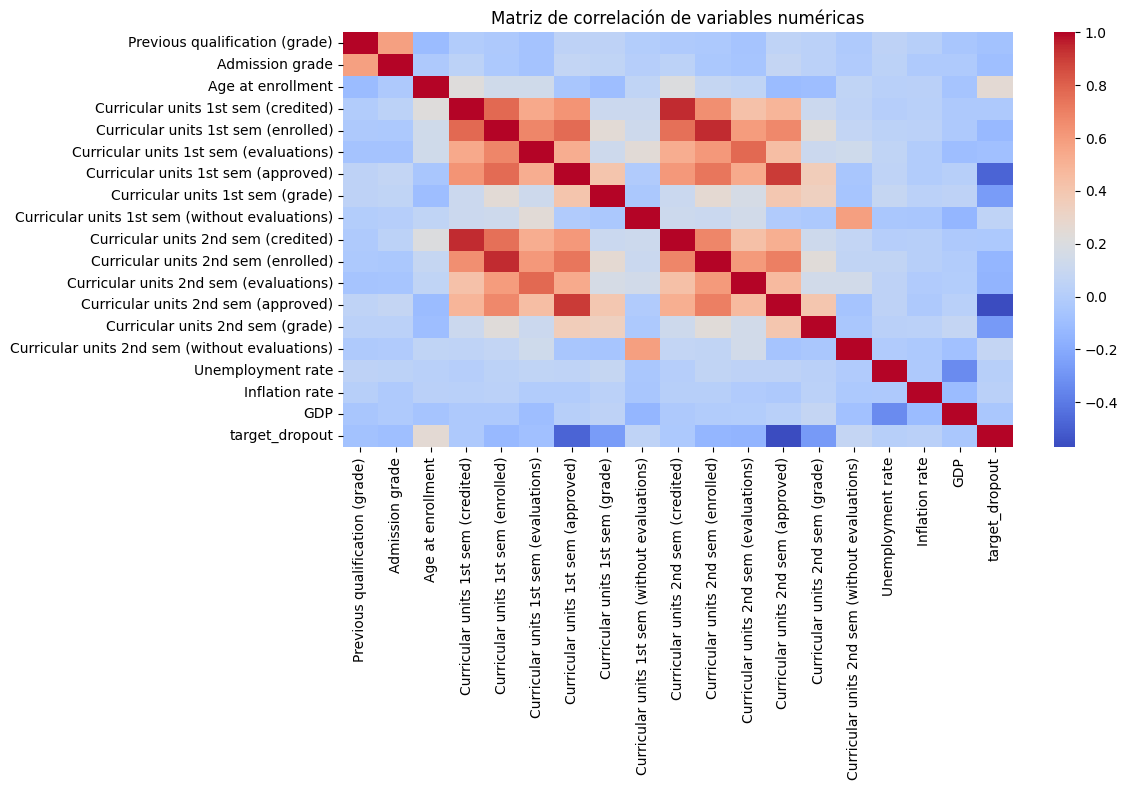


Variables más relacionadas con deserción:
Age at enrollment                                 0.254215
Curricular units 2nd sem (without evaluations)    0.079901
Curricular units 1st sem (without evaluations)    0.054230
Inflation rate                                    0.027826
Unemployment rate                                 0.012980
Curricular units 1st sem (credited)              -0.029308
Curricular units 2nd sem (credited)              -0.033038
GDP                                              -0.046319
Previous qualification (grade)                   -0.078208
Curricular units 1st sem (evaluations)           -0.090125
Name: target_dropout, dtype: float64


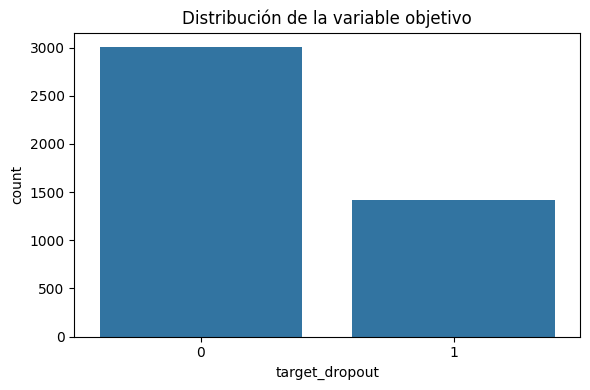

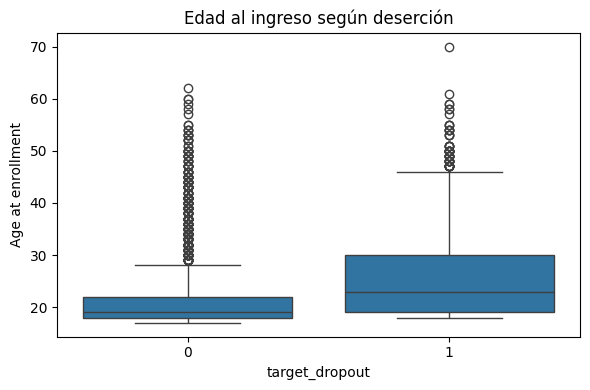


BALANCE DE CLASES
   Clase  Frecuencia  Porcentaje
0      0        3003       67.88
1      1        1421       32.12

Ratio de desbalance: 2.11
Desbalance moderado


In [ ]:
# ============================================================
# 13. ESTADÍSTICA DESCRIPTIVA
# ============================================================

print("\n==============================")
print("ESTADÍSTICA DESCRIPTIVA")
print("==============================")

desc = df[columnas_numericas + ["target_dropout"]].describe().T
print(desc)

# Guardar
desc.to_excel(OUTPUT_CAP4 / "estadistica_descriptiva.xlsx")

# ============================================================
# 14. MATRIZ DE CORRELACIÓN
# ============================================================

print("\n==============================")
print("MATRIZ DE CORRELACIÓN")
print("==============================")

corr = df[columnas_numericas + ["target_dropout"]].corr()

# Guardar
corr.to_excel(OUTPUT_CAP4 / "correlacion.xlsx")

# Heatmap
plt.figure(figsize=(12, 8))
import seaborn as sns
sns.heatmap(corr, cmap="coolwarm")
plt.title("Matriz de correlación de variables numéricas")
plt.tight_layout()
plt.savefig(OUTPUT_CAP4 / "heatmap_correlacion.png", dpi=300)
plt.show()

# Correlación con target
corr_target = corr["target_dropout"].drop("target_dropout").sort_values(ascending=False)

print("\nVariables más relacionadas con deserción:")
print(corr_target.head(10))

corr_target.to_excel(OUTPUT_CAP4 / "correlacion_target.xlsx")

# ============================================================
# 15. DISTRIBUCIÓN DEL TARGET
# ============================================================

plt.figure(figsize=(6, 4))
sns.countplot(x="target_dropout", data=df)
plt.title("Distribución de la variable objetivo")
plt.tight_layout()
plt.savefig(OUTPUT_CAP4 / "grafica_target.png", dpi=300)
plt.show()

# ============================================================
# 16. BOXPLOT VARIABLE CLAVE (EDAD)
# ============================================================

if "Age at enrollment" in df.columns:
    plt.figure(figsize=(6, 4))
    sns.boxplot(x="target_dropout", y="Age at enrollment", data=df)
    plt.title("Edad al ingreso según deserción")
    plt.tight_layout()
    plt.savefig(OUTPUT_CAP4 / "boxplot_edad.png", dpi=300)
    plt.show()

# ============================================================
# 17. BALANCE DE CLASES
# ============================================================

print("\n==============================")
print("BALANCE DE CLASES")
print("==============================")

conteo = y.value_counts()
porcentaje = y.value_counts(normalize=True) * 100

balance = pd.DataFrame({
    "Clase": conteo.index,
    "Frecuencia": conteo.values,
    "Porcentaje": porcentaje.values.round(2)
})

print(balance)

balance.to_excel(OUTPUT_CAP4 / "balance_clases.xlsx", index=False)

# Evaluación del desbalance
ratio = porcentaje.max() / porcentaje.min()

print("\nRatio de desbalance:", round(ratio, 2))

if ratio < 1.5:
    print("Desbalance bajo")
elif ratio < 3:
    print("Desbalance moderado")
else:
    print("Desbalance alto")

In [ ]:
# ============================================================
# 18. DIVISIÓN TRAIN / TEST
# ============================================================

from sklearn.model_selection import train_test_split

# Se separa primero un conjunto de prueba independiente.
# La validación cruzada se realizará solo sobre el conjunto de entrenamiento.

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=RANDOM_STATE
)

print("\nDivisión train/test realizada:")
print("Train:", X_train.shape)
print("Test:", X_test.shape)
print("\nDistribución en train:")
print(y_train.value_counts(normalize=True).round(4))
print("\nDistribución en test:")
print(y_test.value_counts(normalize=True).round(4))

# ============================================================
# 19. PREPROCESAMIENTO PARA MODELADO
# ============================================================

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

# ------------------------------------------------------------
# Transformación para variables numéricas
# ------------------------------------------------------------
# Se aplica imputación por mediana y escalamiento estándar.
# La imputación se mantiene aunque no existan nulos, porque permite
# que el pipeline sea robusto ante futuras bases con valores faltantes.

transformador_numerico = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# ------------------------------------------------------------
# Transformación para variables categóricas
# ------------------------------------------------------------
# Las variables categóricas codificadas numéricamente se imputan
# con la categoría más frecuente y luego se transforman mediante
# One-Hot Encoding para evitar relaciones ordinales artificiales.

transformador_categorico = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

# ------------------------------------------------------------
# Integración del preprocesamiento
# ------------------------------------------------------------
# ColumnTransformer permite aplicar transformaciones distintas
# según el tipo de variable dentro del mismo pipeline.

preprocesador = ColumnTransformer(
    transformers=[
        ("num", transformador_numerico, columnas_numericas),
        ("cat", transformador_categorico, columnas_categoricas)
    ]
)

print("\nPreprocesador definido correctamente.")
print("Variables numéricas procesadas:", len(columnas_numericas))
print("Variables categóricas procesadas:", len(columnas_categoricas))


División train/test realizada:
Train: (3539, 36)
Test: (885, 36)

Distribución en train:
target_dropout
0    0.6787
1    0.3213
Name: proportion, dtype: float64

Distribución en test:
target_dropout
0    0.6791
1    0.3209
Name: proportion, dtype: float64

Preprocesador definido correctamente.
Variables numéricas procesadas: 18
Variables categóricas procesadas: 18


In [ ]:
# ============================================================
# 20. DEFINICIÓN DE MODELOS
# ============================================================

from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# ------------------------------------------------------------
# Balanceo para XGBoost
# ------------------------------------------------------------
# scale_pos_weight se calcula como:
# número de casos negativos / número de casos positivos.
# Esto ayuda a que XGBoost considere el desbalance entre clases.

negativos = (y_train == 0).sum()
positivos = (y_train == 1).sum()

scale_pos_weight = negativos / positivos

print("\nCasos no deserción:", negativos)
print("Casos deserción:", positivos)
print("scale_pos_weight para XGBoost:", round(scale_pos_weight, 4))

# ------------------------------------------------------------
# Modelos seleccionados
# ------------------------------------------------------------

modelos = {
    "Regresion_Logistica": LogisticRegression(
        max_iter=3000,
        class_weight="balanced",
        random_state=RANDOM_STATE
    ),

    "Random_Forest": RandomForestClassifier(
        n_estimators=300,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),

    "XGBoost": XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=5,
        subsample=0.9,
        colsample_bytree=0.9,
        scale_pos_weight=scale_pos_weight,
        eval_metric="logloss",
        random_state=RANDOM_STATE,
        n_jobs=-1
    )
}

print("\nModelos definidos correctamente:")
for nombre in modelos.keys():
    print("-", nombre)

# ============================================================
# 21. VALIDACIÓN CRUZADA ESTRATIFICADA SOBRE TRAIN
# ============================================================

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc"
}

resultados_cv = []

for nombre, modelo in modelos.items():

    pipeline = Pipeline(steps=[
        ("preprocessor", preprocesador),
        ("model", modelo)
    ])

    scores = cross_validate(
        pipeline,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=-1,
        return_train_score=False
    )

    resultados_cv.append({
        "Modelo": nombre,
        "Accuracy_media": scores["test_accuracy"].mean(),
        "Accuracy_std": scores["test_accuracy"].std(),
        "Precision_media": scores["test_precision"].mean(),
        "Precision_std": scores["test_precision"].std(),
        "Recall_media": scores["test_recall"].mean(),
        "Recall_std": scores["test_recall"].std(),
        "F1_media": scores["test_f1"].mean(),
        "F1_std": scores["test_f1"].std(),
        "AUC_ROC_media": scores["test_roc_auc"].mean(),
        "AUC_ROC_std": scores["test_roc_auc"].std()
    })

df_resultados_cv = pd.DataFrame(resultados_cv)

df_resultados_cv = df_resultados_cv.sort_values(
    by=["Recall_media", "F1_media", "AUC_ROC_media"],
    ascending=False
)

print("\nComparación de modelos con validación cruzada sobre train:")
print(df_resultados_cv)

df_resultados_cv.to_excel(
    OUTPUT_CAP5 / "comparacion_modelos_validacion_cruzada.xlsx",
    index=False
)

print("\nResultados de validación cruzada guardados en:")
print(OUTPUT_CAP5 / "comparacion_modelos_validacion_cruzada.xlsx")


Casos no deserción: 2402
Casos deserción: 1137
scale_pos_weight para XGBoost: 2.1126

Modelos definidos correctamente:
- Regresion_Logistica
- Random_Forest
- XGBoost

Comparación de modelos con validación cruzada sobre train:
                Modelo  Accuracy_media  Accuracy_std  Precision_media  Precision_std  Recall_media  Recall_std  F1_media    F1_std  AUC_ROC_media  AUC_ROC_std
0  Regresion_Logistica        0.856741      0.009369         0.763457       0.020112      0.803864    0.018421  0.782896  0.013394       0.920085     0.008048
2              XGBoost        0.866634      0.010188         0.797797       0.017106      0.783635    0.019226  0.790569  0.016311       0.919259     0.008883
1        Random_Forest        0.865784      0.007148         0.858556       0.018275      0.697450    0.015034  0.769510  0.012434       0.915317     0.010589

Resultados de validación cruzada guardados en:
outputs/capitulo_5/comparacion_modelos_validacion_cruzada.xlsx



Mejor modelo seleccionado: Regresion_Logistica

Modelo entrenado correctamente.

Umbral óptimo seleccionado: 0.55

Métricas del modelo final:
                Modelo  Umbral  Accuracy  Precision    Recall        F1   AUC_ROC
0  Regresion_Logistica    0.55  0.884746   0.818182  0.823944  0.821053  0.930655

Matriz de confusión:
                   Pred_No_Desercion  Pred_Desercion
Real_No_Desercion                549              52
Real_Desercion                    50             234


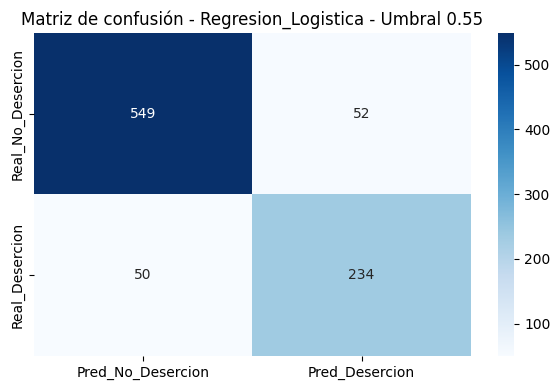


Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.92      0.91      0.92       601
           1       0.82      0.82      0.82       284

    accuracy                           0.88       885
   macro avg       0.87      0.87      0.87       885
weighted avg       0.88      0.88      0.88       885



In [ ]:
# ============================================================
# 22. SELECCIÓN DEL MEJOR MODELO
# ============================================================

# Se selecciona el mejor modelo según la validación cruzada
mejor_modelo_nombre = df_resultados_cv.iloc[0]["Modelo"]
mejor_modelo = modelos[mejor_modelo_nombre]

print("\nMejor modelo seleccionado:", mejor_modelo_nombre)


# ============================================================
# 23. ENTRENAMIENTO FINAL
# ============================================================

pipeline_final = Pipeline(steps=[
    ("preprocessor", preprocesador),
    ("model", mejor_modelo)
])

pipeline_final.fit(X_train, y_train)

print("\nModelo entrenado correctamente.")

# ============================================================
# 24. PROBABILIDADES SOBRE TEST Y EVALUACIÓN DE UMBRALES
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

y_prob = pipeline_final.predict_proba(X_test)[:, 1]

umbrales = np.arange(0.10, 0.91, 0.05)
resultados_umbrales = []

for u in umbrales:
    y_pred_u = (y_prob >= u).astype(int)

    resultados_umbrales.append({
        "Umbral": round(u, 2),
        "Accuracy": accuracy_score(y_test, y_pred_u),
        "Precision": precision_score(y_test, y_pred_u, zero_division=0),
        "Recall": recall_score(y_test, y_pred_u),
        "F1": f1_score(y_test, y_pred_u)
    })

df_umbrales = pd.DataFrame(resultados_umbrales)

df_umbrales.to_excel(
    OUTPUT_CAP5 / "evaluacion_umbrales.xlsx",
    index=False
)

# Se selecciona el umbral que maximiza F1 manteniendo recall mínimo de 0.70.
candidatos = df_umbrales[df_umbrales["Recall"] >= 0.70]

if candidatos.empty:
    umbral_optimo = df_umbrales.loc[df_umbrales["Recall"].idxmax(), "Umbral"]
else:
    umbral_optimo = candidatos.loc[candidatos["F1"].idxmax(), "Umbral"]

print("\nUmbral óptimo seleccionado:", umbral_optimo)

y_pred = (y_prob >= umbral_optimo).astype(int)

# ============================================================
# 25. MÉTRICAS FINALES Y MATRIZ DE CONFUSIÓN
# ============================================================

from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

metricas_finales = pd.DataFrame([{
    "Modelo": mejor_modelo_nombre,
    "Umbral": umbral_optimo,
    "Accuracy": accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred),
    "Recall": recall_score(y_test, y_pred),
    "F1": f1_score(y_test, y_pred),
    "AUC_ROC": roc_auc_score(y_test, y_prob)
}])

print("\nMétricas del modelo final:")
print(metricas_finales)

metricas_finales.to_excel(
    OUTPUT_CAP5 / "metricas_modelo_final.xlsx",
    index=False
)

cm = confusion_matrix(y_test, y_pred)

df_cm = pd.DataFrame(
    cm,
    index=["Real_No_Desercion", "Real_Desercion"],
    columns=["Pred_No_Desercion", "Pred_Desercion"]
)

print("\nMatriz de confusión:")
print(df_cm)

df_cm.to_excel(OUTPUT_CAP5 / "matriz_confusion.xlsx")

# Visualización
plt.figure(figsize=(6, 4))
sns.heatmap(df_cm, annot=True, fmt="d", cmap="Blues")
plt.title(f"Matriz de confusión - {mejor_modelo_nombre} - Umbral {umbral_optimo:.2f}")
plt.tight_layout()
plt.savefig(OUTPUT_CAP5 / "matriz_confusion.png", dpi=300)
plt.show()

# Reporte completo
print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred))

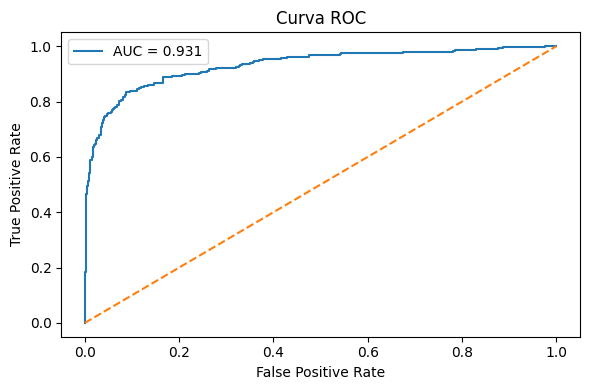

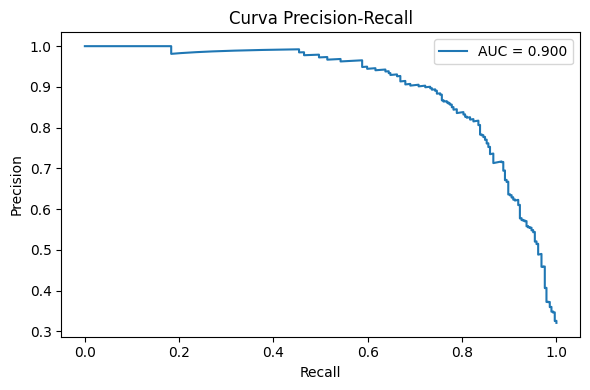

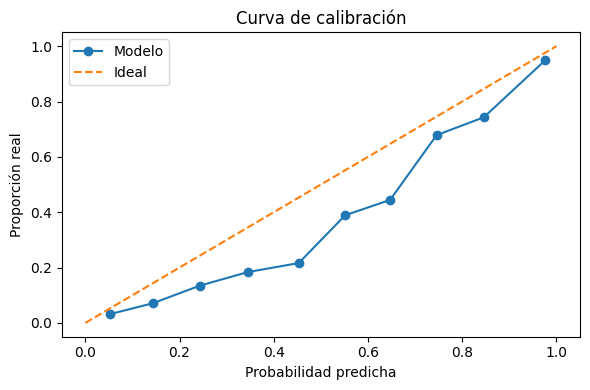

In [ ]:
# ============================================================
# 26. CURVA ROC
# ============================================================

from sklearn.metrics import roc_curve, precision_recall_curve, auc

# Curva ROC
fpr, tpr, thresholds_roc = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curva ROC")
plt.legend()
plt.tight_layout()
plt.savefig(OUTPUT_CAP5 / "curva_roc.png", dpi=300)
plt.show()

# ============================================================
# 27. CURVA PRECISION - RECALL
# ============================================================

precision, recall, thresholds_pr = precision_recall_curve(y_test, y_prob)
pr_auc = auc(recall, precision)

plt.figure(figsize=(6, 4))
plt.plot(recall, precision, label=f"AUC = {pr_auc:.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Curva Precision-Recall")
plt.legend()
plt.tight_layout()
plt.savefig(OUTPUT_CAP5 / "curva_precision_recall.png", dpi=300)
plt.show()

from sklearn.calibration import calibration_curve

prob_true, prob_pred = calibration_curve(
    y_test,
    y_prob,
    n_bins=10
)

plt.figure(figsize=(6, 4))
plt.plot(prob_pred, prob_true, marker="o", label="Modelo")
plt.plot([0, 1], [0, 1], linestyle="--", label="Ideal")
plt.xlabel("Probabilidad predicha")
plt.ylabel("Proporción real")
plt.title("Curva de calibración")
plt.legend()
plt.tight_layout()
plt.savefig(
    OUTPUT_CAP5 / "curva_calibracion.png",
    dpi=300
)
plt.show()



INTERPRETABILIDAD CON SHAP

Top 15 coeficientes:
                        Variable_transformada  Coeficiente  Abs_Coeficiente
12   num__Curricular units 2nd sem (approved)    -1.914078         1.914078
189              cat__Mother's occupation_191    -1.864882         1.864882
162                cat__Mother's occupation_0     1.301844         1.301844
107             cat__Mother's qualification_4    -1.295317         1.295317
103                      cat__Nacionality_109     1.254508         1.254508
204               cat__Father's occupation_90     1.189798         1.189798
243            cat__Tuition fees up to date_1    -1.153249         1.153249
72              cat__Previous qualification_4     1.134614         1.134614
242            cat__Tuition fees up to date_0     1.117685         1.117685
170                cat__Mother's occupation_8     1.113533         1.113533
65                           cat__Course_9853     1.095570         1.095570
173               cat__Mother's occupa

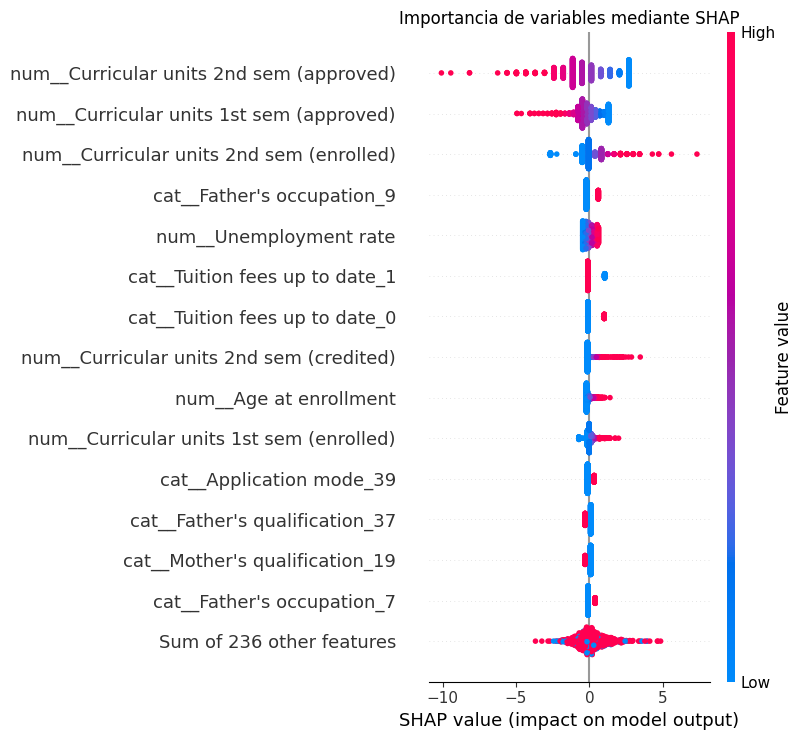


Top 15 variables más importantes según SHAP:
                        Variable_transformada  SHAP_mean_abs
12   num__Curricular units 2nd sem (approved)       1.588401
6    num__Curricular units 1st sem (approved)       0.713779
10   num__Curricular units 2nd sem (enrolled)       0.591605
202                cat__Father's occupation_9       0.296225
15                     num__Unemployment rate       0.277599
243            cat__Tuition fees up to date_1       0.225607
242            cat__Tuition fees up to date_0       0.218649
9    num__Curricular units 2nd sem (credited)       0.216347
2                      num__Age at enrollment       0.194740
4    num__Curricular units 1st sem (enrolled)       0.165282
35                   cat__Application mode_39       0.156775
155            cat__Father's qualification_37       0.152257
115            cat__Mother's qualification_19       0.139345
200                cat__Father's occupation_7       0.129123
18                      cat__Marital st

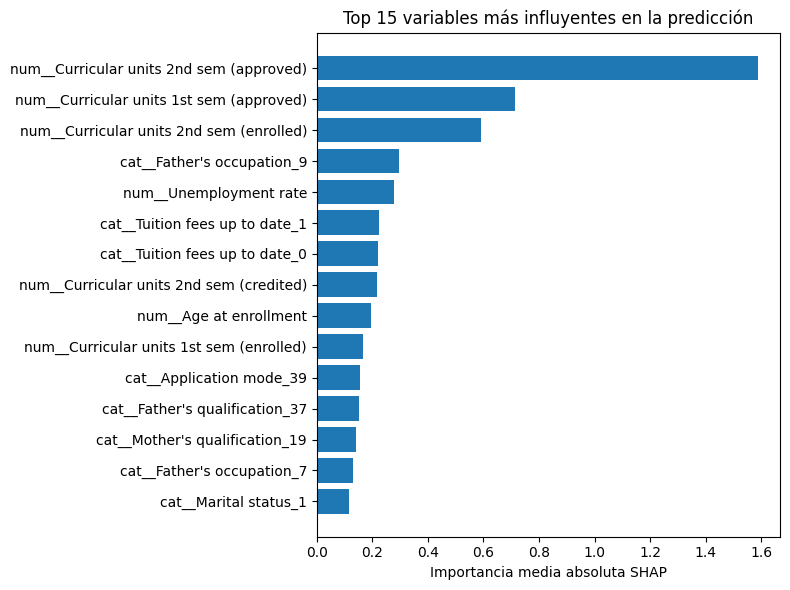


Resultados SHAP guardados correctamente.


In [ ]:
# ============================================================
# 28. INTERPRETABILIDAD DEL MODELO CON SHAP
# ============================================================

# SHAP permite analizar la contribución de cada variable en la predicción.
# En este bloque se trabaja sobre el modelo final ya entrenado.

print("\n==============================")
print("INTERPRETABILIDAD CON SHAP")
print("==============================")

# Extraer preprocesador y modelo entrenado
preprocessor_fit = pipeline_final.named_steps["preprocessor"]
modelo_fit = pipeline_final.named_steps["model"]


# ============================================================
# COEFICIENTES SI ES REGRESIÓN LOGÍSTICA
# ============================================================

if mejor_modelo_nombre == "Regresion_Logistica":

    feature_names_coef = preprocessor_fit.get_feature_names_out()
    coeficientes = modelo_fit.coef_[0]

    df_coeficientes = pd.DataFrame({
        "Variable_transformada": feature_names_coef,
        "Coeficiente": coeficientes,
        "Abs_Coeficiente": np.abs(coeficientes)
    }).sort_values("Abs_Coeficiente", ascending=False)

    print("\nTop 15 coeficientes:")
    print(df_coeficientes.head(15))

    df_coeficientes.to_excel(
        OUTPUT_CAP5 / "coeficientes_logistica.xlsx",
        index=False
    )


# Transformar datos de entrenamiento y prueba
X_train_transf = preprocessor_fit.transform(X_train)
X_test_transf = preprocessor_fit.transform(X_test)

# Obtener nombres de variables luego del preprocesamiento
feature_names = preprocessor_fit.get_feature_names_out()

# Convertir a formato denso si es necesario
if hasattr(X_train_transf, "toarray"):
    X_train_transf = X_train_transf.toarray()

if hasattr(X_test_transf, "toarray"):
    X_test_transf = X_test_transf.toarray()

# ------------------------------------------------------------
# Muestra de referencia para SHAP
# ------------------------------------------------------------
# Se usa una muestra del conjunto de entrenamiento para reducir
# el costo computacional y mantener estabilidad en la explicación.

background_size = min(200, X_train_transf.shape[0])
background = X_train_transf[:background_size]

# ------------------------------------------------------------
# Creación del explicador SHAP
# ------------------------------------------------------------

explainer = shap.Explainer(
    modelo_fit,
    background,
    feature_names=feature_names
)

shap_values = explainer(X_test_transf)

# ============================================================
# 29. GRÁFICO SHAP SUMMARY
# ============================================================

plt.figure()
shap.plots.beeswarm(
    shap_values,
    max_display=15,
    show=False
)

plt.title("Importancia de variables mediante SHAP")
plt.tight_layout()
plt.savefig(
    OUTPUT_CAP5 / "shap_summary.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

# ============================================================
# 30. IMPORTANCIA MEDIA ABSOLUTA SHAP
# ============================================================

mean_abs_shap = np.abs(shap_values.values).mean(axis=0)

df_shap = pd.DataFrame({
    "Variable_transformada": feature_names,
    "SHAP_mean_abs": mean_abs_shap
}).sort_values(
    "SHAP_mean_abs",
    ascending=False
)

print("\nTop 15 variables más importantes según SHAP:")
print(df_shap.head(15))

df_shap.to_excel(
    OUTPUT_CAP5 / "shap_importancia_variables.xlsx",
    index=False
)

# ============================================================
# 31. GRÁFICO DE BARRAS SHAP
# ============================================================

top_shap = df_shap.head(15).sort_values("SHAP_mean_abs")

plt.figure(figsize=(8, 6))
plt.barh(
    top_shap["Variable_transformada"],
    top_shap["SHAP_mean_abs"]
)
plt.xlabel("Importancia media absoluta SHAP")
plt.title("Top 15 variables más influyentes en la predicción")
plt.tight_layout()
plt.savefig(
    OUTPUT_CAP5 / "shap_importancia_barras.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

print("\nResultados SHAP guardados correctamente.")


Percentil 33: 0.1031
Percentil 66: 0.5022

Distribución de segmentos de riesgo:
segmento_riesgo
Alto     301
Bajo     292
Medio    292
Name: count, dtype: int64


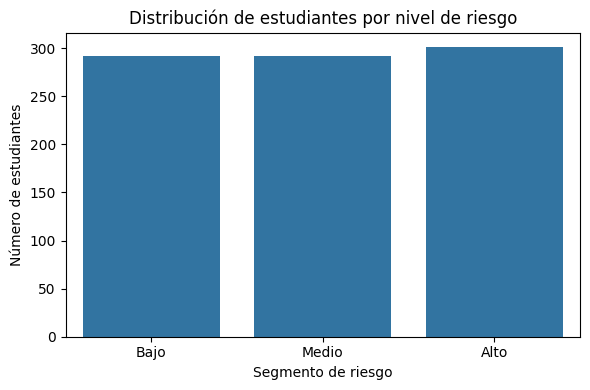


Resumen por segmento:
  segmento_riesgo  estudiantes  probabilidad_promedio  desercion_real_promedio
0            Alto          301                 0.8608                   0.7907
1            Bajo          292                 0.0521                   0.0308
2           Medio          292                 0.2460                   0.1267

Modelo final guardado en:
models/modelo_final_desercion.pkl

Configuración del modelo guardada.

Pipeline ejecutado correctamente.
Archivos principales generados:
- outputs/versions.json
- outputs/capitulo_4/base_limpia.xlsx
- outputs/capitulo_4/tabla_variables.xlsx
- outputs/capitulo_5/comparacion_modelos_validacion_cruzada.xlsx
- outputs/capitulo_5/metricas_modelo_final.xlsx
- outputs/capitulo_5/matriz_confusion.xlsx
- outputs/capitulo_5/curva_roc.png
- outputs/capitulo_5/curva_precision_recall.png
- outputs/capitulo_5/shap_summary.png
- outputs/capitulo_5/segmentacion_riesgo.xlsx
- models/modelo_final_desercion.pkl


In [ ]:
# ============================================================
# 32. SEGMENTACIÓN DE RIESGO
# ============================================================

# La segmentación se construye a partir de las probabilidades
# estimadas por el modelo final. Esta clasificación permite convertir
# la predicción en una herramienta operativa para la toma de decisiones.

p33 = np.percentile(y_prob, 33)
p66 = np.percentile(y_prob, 66)

print("\nPercentil 33:", round(p33, 4))
print("Percentil 66:", round(p66, 4))

def segmentar_riesgo(probabilidad, corte_bajo, corte_alto):
    if probabilidad <= corte_bajo:
        return "Bajo"
    elif probabilidad <= corte_alto:
        return "Medio"
    else:
        return "Alto"

df_segmentacion = X_test.copy()
df_segmentacion["probabilidad_desercion"] = y_prob
df_segmentacion["prediccion_desercion"] = y_pred
df_segmentacion["target_real"] = y_test.values

df_segmentacion["segmento_riesgo"] = df_segmentacion["probabilidad_desercion"].apply(
    lambda p: segmentar_riesgo(p, p33, p66)
)

print("\nDistribución de segmentos de riesgo:")
print(df_segmentacion["segmento_riesgo"].value_counts())

df_segmentacion.to_excel(
    OUTPUT_CAP5 / "segmentacion_riesgo.xlsx",
    index=False
)

# Gráfico de segmentos
plt.figure(figsize=(6, 4))
sns.countplot(
    x="segmento_riesgo",
    data=df_segmentacion,
    order=["Bajo", "Medio", "Alto"]
)
plt.title("Distribución de estudiantes por nivel de riesgo")
plt.xlabel("Segmento de riesgo")
plt.ylabel("Número de estudiantes")
plt.tight_layout()
plt.savefig(
    OUTPUT_CAP5 / "distribucion_segmentos_riesgo.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

# ============================================================
# 33. RESUMEN DE SEGMENTACIÓN
# ============================================================

resumen_segmentos = df_segmentacion.groupby("segmento_riesgo").agg(
    estudiantes=("segmento_riesgo", "count"),
    probabilidad_promedio=("probabilidad_desercion", "mean"),
    desercion_real_promedio=("target_real", "mean")
).reset_index()

resumen_segmentos["probabilidad_promedio"] = resumen_segmentos["probabilidad_promedio"].round(4)
resumen_segmentos["desercion_real_promedio"] = resumen_segmentos["desercion_real_promedio"].round(4)

print("\nResumen por segmento:")
print(resumen_segmentos)

resumen_segmentos.to_excel(
    OUTPUT_CAP5 / "resumen_segmentos_riesgo.xlsx",
    index=False
)

# ============================================================
# 34. GUARDADO DEL MODELO FINAL
# ============================================================

import joblib

modelo_path = MODEL_DIR / "modelo_final_desercion.pkl"

joblib.dump(pipeline_final, modelo_path)

print("\nModelo final guardado en:")
print(modelo_path)

# ============================================================
# 35. GUARDADO DE CONFIGURACIÓN DEL MODELO
# ============================================================

config_modelo = {
    "modelo_seleccionado": mejor_modelo_nombre,
    "random_state": RANDOM_STATE,
    "target": "target_dropout",
    "descripcion_target": "1 = deserción, 0 = no deserción",
    "criterio_seleccion": "Mayor recall promedio en validación cruzada, complementado con F1 y AUC-ROC",
    "umbral_clasificacion": {
        "valor": float(umbral_optimo),
        "criterio": "Maximizar F1 manteniendo recall mínimo de 0.70"
    },
    "segmentacion": {
        "metodo": "Percentiles sobre probabilidades estimadas",
        "percentil_33": float(p33),
        "percentil_66": float(p66),
        "riesgo_bajo": f"probabilidad <= {round(p33, 4)}",
        "riesgo_medio": f"{round(p33, 4)} < probabilidad <= {round(p66, 4)}",
        "riesgo_alto": f"probabilidad > {round(p66, 4)}"
    }
}

with open(OUTPUT_CAP5 / "configuracion_modelo.json", "w", encoding="utf-8") as file:
    json.dump(config_modelo, file, indent=4, ensure_ascii=False)

print("\nConfiguración del modelo guardada.")

# ============================================================
# 36. MENSAJE FINAL
# ============================================================

print("\nPipeline ejecutado correctamente.")
print("Archivos principales generados:")
print("- outputs/versions.json")
print("- outputs/capitulo_4/base_limpia.xlsx")
print("- outputs/capitulo_4/tabla_variables.xlsx")
print("- outputs/capitulo_5/comparacion_modelos_validacion_cruzada.xlsx")
print("- outputs/capitulo_5/metricas_modelo_final.xlsx")
print("- outputs/capitulo_5/matriz_confusion.xlsx")
print("- outputs/capitulo_5/curva_roc.png")
print("- outputs/capitulo_5/curva_precision_recall.png")
print("- outputs/capitulo_5/shap_summary.png")
print("- outputs/capitulo_5/segmentacion_riesgo.xlsx")
print("- models/modelo_final_desercion.pkl")

In [ ]:
%%writefile requirements.txt
numpy
pandas
matplotlib
seaborn
scikit-learn
xgboost
shap
openpyxl
joblib

Writing requirements.txt


In [ ]:
%%writefile README.md
# Predicción de deserción estudiantil

Este proyecto desarrolla un modelo de machine learning para identificar estudiantes en riesgo de deserción.

## Modelos

- Regresión logística
- Random Forest
- XGBoost

## Métricas

- Accuracy
- Precision
- Recall
- F1-score
- AUC-ROC

Se prioriza recall porque el objetivo principal es identificar correctamente a los estudiantes que podrían desertar.

## Ejecución

1. Colocar el archivo BDF.xlsx dentro de la carpeta data/.
2. Instalar dependencias con:

pip install -r requirements.txt

3. Ejecutar el script principal.

## Salidas principales

- Comparación de modelos
- Matriz de confusión
- Curva ROC
- Curva Precision-Recall
- Curva de calibración
- Análisis SHAP
- Segmentación de riesgo
- Modelo final guardado

Writing README.md


In [ ]:
import os
os.listdir()

['.config',
 'data',
 'README.md',
 'requirements.txt',
 'outputs',
 'models',
 'sample_data']